# **本notebook的重點在於最後的「股價組合與夏普比率計算」，主要目的在於預測股價組合的好壞**

In [ ]:
!pip install yfinance
!pip install yahoofinancials

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.9/51.9 kB 1.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for yahoofinancials: filename=yahoofinancials-1.20-py3-none-any.whl size=38618 sha256=debe4870dea7b97a1c5a2e422a9855c3cbc83476f4ff42a9f29cf5f44dbe4394
  Stored in directory: /root/.cache/pip/wheels/c6/bc/18/da12b3c280d31beeac0c0f491c8f370da7c1473a56d7d4b5f3
Successfully built yahoofinancials


# yf.Ticker("股票代碼")

In [ ]:
import yfinance as yf
import pandas as pd
tsmc = yf.Ticker("2330.TW")

#獲取歷史市場數據


hist_data_1y = tsmc.history(period = "1y")
print("---台積電過去一年日線數據")
print(hist_data_1y.tail())

hist_data_custom = tsmc.history(start = "2023-01-01", end = "2025-06-03", interval = "1d")
print("\n---台積電2023上半年日線數據(部分)---")
print(hist_data_custom.tail())

---台積電過去一年日線數據
                                 Open         High          Low        Close  \
Date                                                                           
2025-06-10 00:00:00+08:00  1020.66898  1045.563346  1015.690107  1040.584473   
2025-06-11 00:00:00+08:00  1060.50000  1065.478873  1050.542254  1060.500000   
2025-06-12 00:00:00+08:00  1055.00000  1060.000000  1045.000000  1045.000000   
2025-06-13 00:00:00+08:00  1040.00000  1040.000000  1025.000000  1030.000000   
2025-06-16 00:00:00+08:00  1030.00000  1030.000000  1020.000000  1025.000000   

                             Volume  Dividends  Stock Splits  
Date                                                          
2025-06-10 00:00:00+08:00  44877640        0.0           0.0  
2025-06-11 00:00:00+08:00  37178498        0.0           0.0  
2025-06-12 00:00:00+08:00  25221606        4.5           0.0  
2025-06-13 00:00:00+08:00  28393455        0.0           0.0  
2025-06-16 00:00:00+08:00   7787314        0.0

# get more **information**

In [ ]:
#獲取股票資訊
#info = tsmc.info
info = pd.Series(tsmc.info)
info

,0
address1,Hsinchu Science Park
address2,"No. 8, Li-Hsin Road 6"
city,Hsinchu City
zip,300096
country,Taiwan
...,...
earningsCallTimestampStart,1744869600
earningsCallTimestampEnd,1744869600
isEarningsDateEstimate,True
firstTradeDateMilliseconds,946947600000


In [ ]:
TSMC = yf.download("2330.TW", start = "2023-01-01", end = "2025-06-03", progress = True)
TSMC

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,2330.TW,2330.TW,2330.TW,2330.TW,2330.TW
Date,,,,,
2023-01-03,436.091095,436.572432,426.464360,429.352380,14885824
2023-01-04,432.721710,438.016414,431.759037,432.721710,19188422
2023-01-05,441.385803,442.348477,438.016446,441.867140,23549581
2023-01-06,441.385803,442.348477,438.016446,438.016446,20886011
2023-01-09,463.045929,463.045929,450.049837,450.531174,46666263
...,...,...,...,...,...
2025-05-26,971.876038,979.842235,970.880263,970.880263,19329052
2025-05-27,960.922485,970.880231,956.939387,966.897133,26355315


In [ ]:
data = yf.download(["AAPL", "TSLA"], period = "1y")
data

[*********************100%***********************]  2 of 2 completed


Price            Close                    High                     Low  \
Ticker            AAPL        TSLA        AAPL        TSLA        AAPL   
Date                                                                     
2024-06-14  211.500870  178.009995  214.168387  186.000000  210.316407   
2024-06-17  215.661423  187.440002  217.930808  188.809998  211.729813   
2024-06-18  213.292480  184.860001  217.612289  187.199997  212.008492   
2024-06-20  208.703949  181.570007  213.242735  185.210007  207.877826   
2024-06-21  206.524155  183.009995  210.903667  183.949997  206.145919   
...                ...         ...         ...         ...         ...   
2025-06-09  201.449997  308.579987  206.000000  309.829987  200.020004   
2025-06-10  202.669998  326.089996  204.350006  327.829987  200.570007   
2025-06-11  198.779999  326.429993  204.500000  335.500000  198.410004   
2025-06-12  199.199997  319.109985  199.679993  332.559998  197.360001   
2025-06-13  196.449997  325.309998  200.369995  332.989990  195.699997   

Price                         Open                 Volume             
Ticker            TSLA        AAPL        TSLA       AAPL       TSLA  
Date                                                                  
2024-06-14  176.919998  212.854540  185.800003   70122700   82038200  
2024-06-17  177.000000  212.376781  177.919998   93728300  109786100  
2024-06-18  182.369995  216.577122  186.559998   79943300   68982300  
2024-06-20  179.660004  212.934166  184.679993   86172500   55893100  
2024-06-21  180.690002  209.410649  182.300003  246421400   63029500  
...                ...         ...         ...        ...        ...  
2025-06-09  281.850006  204.389999  285.959991   72862600  140908900  
2025-06-10  310.670013  200.600006  314.940002   54672600  151256500  
2025-06-11  322.500000  203.500000  334.399994   60989900  122611400  
2025-06-12  316.859985  199.080002  323.079987   43904600  105127500  
2025-06-13  313.299988  199.729996  313.970001   51362400  128495300  

[250 rows x 10 columns]

In [ ]:
data = yf.download(["AAPL", "TSLA"], start = "2023-01-01", end = "2025-06-03", progress = True)
data

[*********************100%***********************]  2 of 2 completed


Price            Close                    High                     Low  \
Ticker            AAPL        TSLA        AAPL        TSLA        AAPL   
Date                                                                     
2023-01-03  123.470619  108.099998  129.226060  118.800003  122.582127   
2023-01-04  124.744118  113.639999  127.014709  114.589996  123.480487   
2023-01-05  123.421249  110.339996  126.136083  111.750000  123.164580   
2023-01-06  127.962425  113.059998  128.623856  114.389999  123.292916   
2023-01-09  128.485641  119.769997  131.703962  123.519997  128.228972   
...                ...         ...         ...         ...         ...   
2025-05-27  200.210007  362.890015  200.740005  363.790009  197.429993   
2025-05-28  200.419998  356.899994  202.729996  365.000000  199.899994   
2025-05-29  199.949997  358.429993  203.809998  367.709991  198.509995   
2025-05-30  200.850006  346.459991  201.960007  363.679993  196.779999   
2025-06-02  201.699997  342.690002  202.130005  348.019989  200.119995   

Price                         Open                 Volume             
Ticker            TSLA        AAPL        TSLA       AAPL       TSLA  
Date                                                                  
2023-01-03  104.639999  128.613993  118.470001  112117500  231402800  
2023-01-04  107.519997  125.267339  109.110001   89113600  180389000  
2023-01-05  107.160004  125.504267  110.510002   80962700  157986300  
2023-01-06  101.809998  124.398597  103.000000   87754700  220911100  
2023-01-09  117.110001  128.801557  118.959999   70790800  190284000  
...                ...         ...         ...        ...        ...  
2025-05-27  347.320007  198.300003  347.350006   56288500  120146400  
2025-05-28  355.910004  200.589996  364.839996   45339700   91404300  
2025-05-29  356.000000  203.580002  365.290009   51396800   88545700  
2025-05-30  345.290009  199.369995  355.519989   70819900  123474900  
2025-06-02  333.329987  200.279999  343.500000   35423300   81873800  

[605 rows x 10 columns]

In [ ]:
data = yf.download("2330.TW", start = "2024-01-01", end = "2024-06-01")
print(data[["Close"]].head())

data["Return"] = data["Close"].pct_change().dropna()
#print(data[["Close", "Return"]].head())
data[["Close", "Return"]].head()
data[["Close", "Return"]].to_excel("Data1.xlsx")

[*********************100%***********************]  1 of 1 completed


Price            Close
Ticker         2330.TW
Date                  
2024-01-02  582.887573
2024-01-03  568.143372
2024-01-04  570.109253
2024-01-05  566.177429
2024-01-08  573.058105


In [ ]:
AMDR_mean = data["Return"].mean()

print(f"算數平均日報酬率 {AMDR_mean: .5f}")

data_TSLA = yf.download("TSLA", start = "2025-06-01", end = "2025-06-15")

data_TSLA["Return"] = data_TSLA["Close"].pct_change().dropna()
TSLA_mean = data_TSLA["Return"].mean()
print()

print(f"Tesla的算術平均日報酬率: {TSLA_mean}")

[*********************100%***********************]  1 of 1 completed

算數平均日報酬率  0.00360

Tesla的算術平均日報酬率: -0.004053875500290436


In [ ]:
import numpy as np
returns = data["Return"].dropna()
geo_mean = (np.prod(1 + returns))**(1/len(returns)) - 1
print(f"幾何平均日報酬率: {geo_mean: .5f}")

幾何平均日報酬率:  0.00341


In [ ]:
data_SP = yf.download("^GSPC", start = "2025-01-01", end = "2025-06-15")
data_0050 = yf.download("0050.TW", start = "2025-01-01", end = "2025-06-15")
data_0056 = yf.download("0056.TW", start = "2025-01-01", end = "2025-06-15")
data_SP["Return"] = data_SP["Close"].pct_change().dropna()
SP_mean = data_SP["Return"].mean()
SP_return = data_SP["Return"].dropna()
geo_SP = (np.prod(1 + SP_return))**(1/len(SP_return)) - 1

data_0050["Return"] = data_0050["Close"].pct_change().dropna()
data0050_mean = data_0050["Return"].mean()
data0050_return = data_0050["Return"].dropna()
geo_0050 = (np.prod(1 + data0050_return))**(1/len(data0050_return)) - 1

data_0056["Return"] = data_0056["Close"].pct_change().dropna()
data0056_mean = data_0056["Return"].mean()
data0056_return = data_0056["Return"].dropna()
geo_0056 = (np.prod(1 + data0056_return))**(1/len(data0056_return)) - 1

print()
print(f"S&P500的平均日報酬率: {SP_mean}")
print(f"S&P500的幾何日報酬率: {geo_SP}")
print()

print(f"0050的平均日報酬率: {data0050_mean}")
print(f"0050的幾何日報酬率: {geo_0050}")
print()

print(f"0056的平均日報酬率: {data0056_mean}")
print(f"0056的幾何日報酬率: {geo_0056}")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


S&P500的平均日報酬率: 0.0002914943598709016
S&P500的幾何日報酬率: 0.0001649346383219008

0050的平均日報酬率: -0.0072447006727643475
0050的幾何日報酬率: -0.013476660955944908

0056的平均日報酬率: 0.00020045783960889206
0056的幾何日報酬率: 4.484222144340855e-05


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


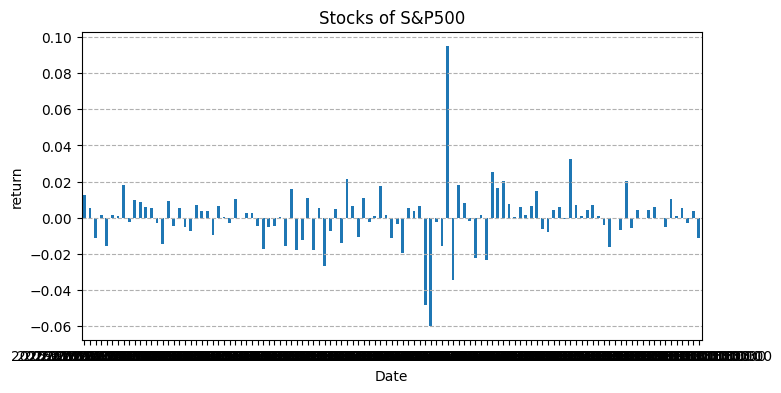

In [ ]:
import matplotlib.pyplot as plt
data_SP = yf.download("^GSPC", start = "2024-01-01", end = "2025-01-01")
data_0050 = yf.download("0050.TW", start = "2024-01-01", end = "2025-01-01")
data_0056 = yf.download("0056.TW", start = "2024-01-01", end = "2025-01-01")

SP_return.plot(kind = "bar", figsize = (8, 4))

plt.title("Stocks of S&P500")
plt.ylabel("return")
plt.xticks(rotation = 0)
plt.grid(axis = "y", linestyle = "--")
plt.show()



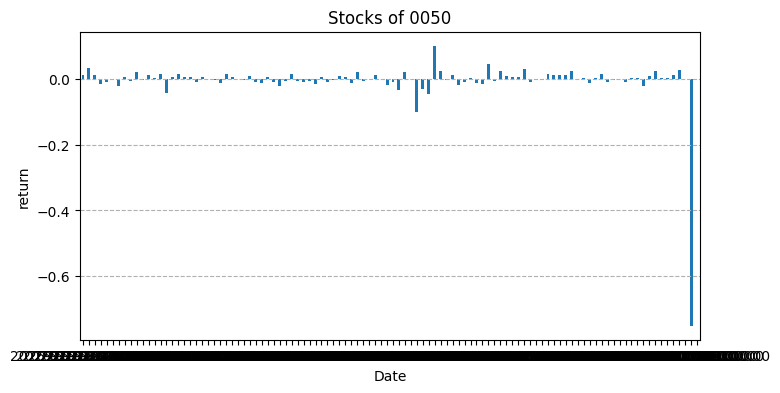

In [ ]:
data0050_return.plot(kind = "bar", figsize = (8, 4))

plt.title("Stocks of 0050")
plt.ylabel("return")
plt.xticks(rotation = 0)
plt.grid(axis = "y", linestyle = "--")
plt.show()


[*********************100%***********************]  1 of 1 completed


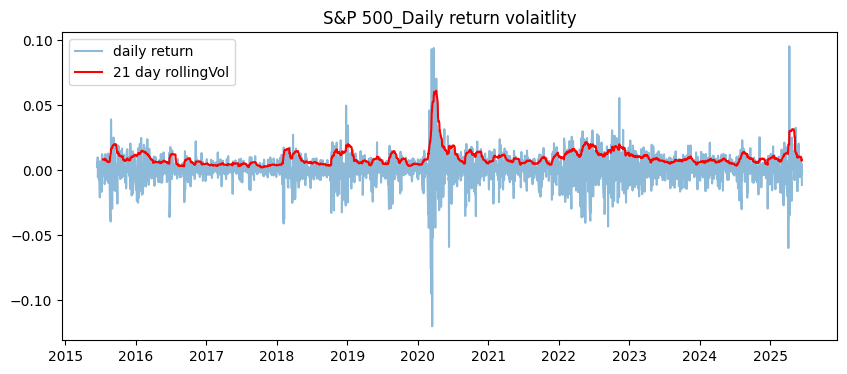

In [ ]:
data = yf.download("^GSPC", period = "10y")
data["Return"] = data["Close"].pct_change().dropna()
window = 21
data["RollingVol"] = data["Return"].rolling(window).std()

plt.figure(figsize = (10, 4))
plt.plot(data["Return"], label = "daily return", alpha = 0.5)
plt.plot(data["RollingVol"], label = "21 day rollingVol", color = "red")
plt.legend()
plt.title("S&P 500_Daily return volaitlity")
plt.show()

[*********************100%***********************]  1 of 1 completed


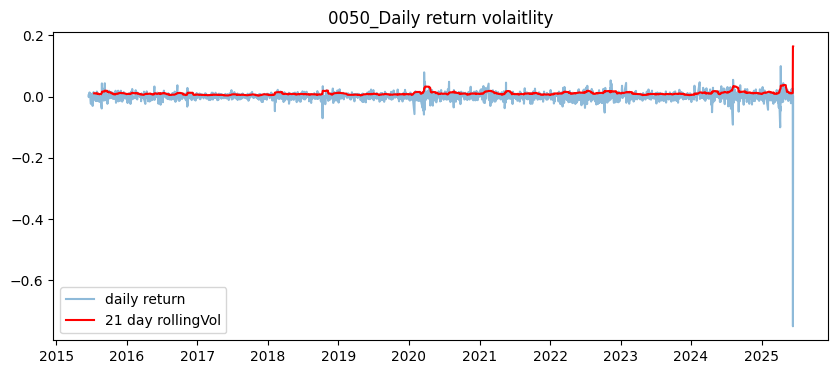

In [ ]:
data = yf.download("0050.TW", period = "10y")
data["Return"] = data["Close"].pct_change().dropna()
window = 21
data["RollingVol"] = data["Return"].rolling(window).std()

plt.figure(figsize = (10, 4))
plt.plot(data["Return"], label = "daily return", alpha = 0.5)
plt.plot(data["RollingVol"], label = "21 day rollingVol", color = "red")
plt.legend()
plt.title("0050_Daily return volaitlity")
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd

#下載0050.TW近一年日資料
df = yf.download("0050.TW", period = "1y")
df["Value"] = df["Close"] * df["Volume"] #計算每日交易額
#print(df[["Close", "Volume", "Value"]].head())
df[["Close", "Volume", "Value"]].head()

<ipython-input-2-2597976432>:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("0050.TW", period = "1y")
[*********************100%***********************]  1 of 1 completed


Price,Close,Volume,Value
Ticker,0050.TW,0050.TW,
Date,,,
2024-06-17,176.643448,8127793,1.435721e+09
2024-06-18,179.587524,6563311,1.178689e+09
2024-06-19,184.445221,25338672,4.673597e+09
2024-06-20,186.211655,11321643,2.108222e+09
2024-06-21,185.083099,10239036,1.895073e+09


In [ ]:
#下載0056.TW近一年日資料
df1 = yf.download("0056.TW", period = "1y")
df1["Value"] = df1["Close"] * df1["Volume"] #計算每日交易額
#print(df[["Close", "Volume", "Value"]].head())
df1[["Close", "Volume", "Value"]].head()

<ipython-input-3-175332797>:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df1 = yf.download("0056.TW", period = "1y")
[*********************100%***********************]  1 of 1 completed


Price,Close,Volume,Value
Ticker,0056.TW,0056.TW,
Date,,,
2024-06-17,36.276806,15172045,5.503933e+08
2024-06-18,36.427990,15858453,5.776916e+08
2024-06-19,36.926029,21645238,7.992727e+08
2024-06-20,37.308456,17997780,6.714694e+08
2024-06-21,37.263985,17338064,6.460854e+08


In [ ]:
#0050交易額變動比例
df["Value_Change"] = df["Value"].pct_change()
print(df[["Value", "Value_Change"]].dropna().head())

print()
print()

#0056
df1["Value_Change"] = df1["Value"].pct_change()
print(df1[["Value", "Value_Change"]].dropna().head())

Price              Value Value_Change
Ticker                               
Date                                 
2024-06-18  1.178689e+09    -0.179027
2024-06-19  4.673597e+09     2.965081
2024-06-20  2.108222e+09    -0.548908
2024-06-21  1.895073e+09    -0.101104
2024-06-24  2.382928e+09     0.257434


Price              Value Value_Change
Ticker                               
Date                                 
2024-06-18  5.776916e+08     0.049598
2024-06-19  7.992727e+08     0.383563
2024-06-20  6.714694e+08    -0.159899
2024-06-21  6.460854e+08    -0.037804
2024-06-24  1.040486e+09     0.610447


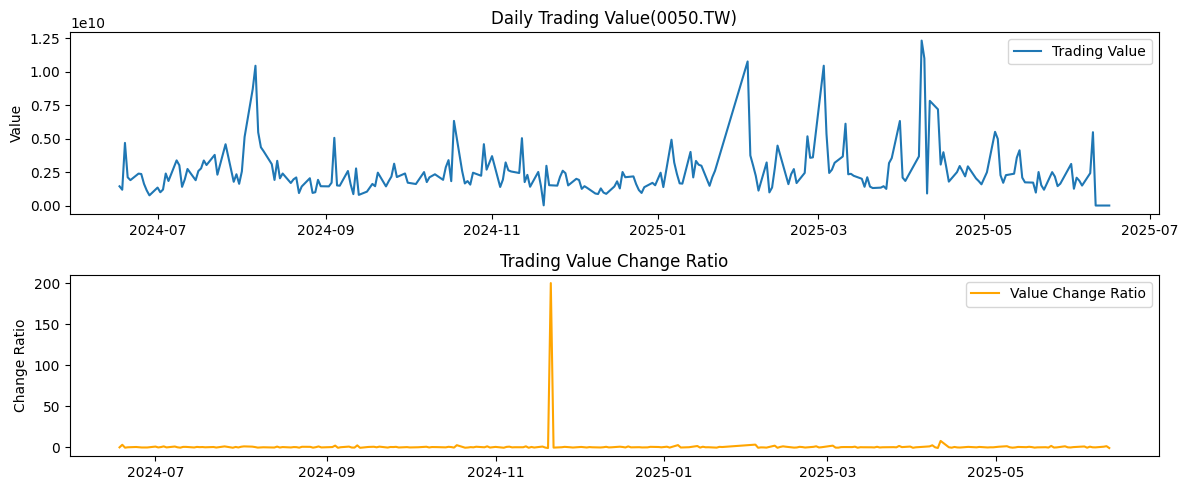

In [ ]:
import matplotlib.pyplot as plt

#0050
plt.figure(figsize = (12, 5))
plt.subplot(2, 1, 1)
plt.plot(df["Value"], label = "Trading Value")
plt.title("Daily Trading Value(0050.TW)")
plt.ylabel("Value")
plt.legend()


plt.subplot(2, 1, 2)
plt.plot(df["Value_Change"], color = "orange", label = "Value Change Ratio")
plt.title("Trading Value Change Ratio")
plt.ylabel("Change Ratio")
plt.legend()
plt.tight_layout()
plt.show()

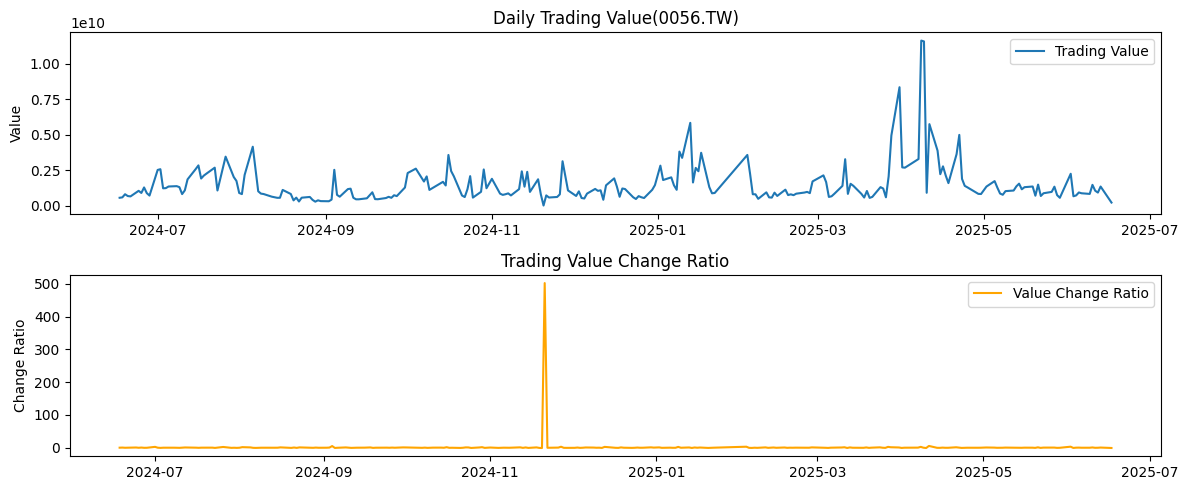

In [ ]:
#0056
plt.figure(figsize = (12, 5))
plt.subplot(2, 1, 1)
plt.plot(df1["Value"], label = "Trading Value")
plt.title("Daily Trading Value(0056.TW)")
plt.ylabel("Value")
plt.legend()


plt.subplot(2, 1, 2)
plt.plot(df1["Value_Change"], color = "orange", label = "Value Change Ratio")
plt.title("Trading Value Change Ratio")
plt.ylabel("Change Ratio")
plt.legend()
plt.tight_layout()
plt.show()


#事件分析法

<ipython-input-16-352838911>:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df2 = yf.download("SPY", period = "1y")
[*********************100%***********************]  1 of 1 completed


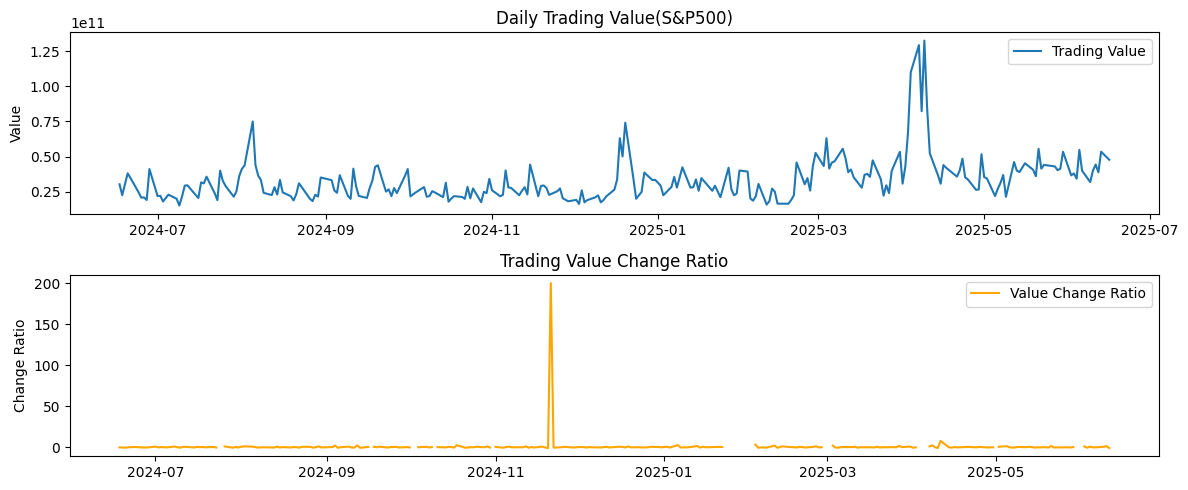

In [ ]:
#S&P500

df2 = yf.download("SPY", period = "1y")
df2["Value"] = df2["Close"] * df2["Volume"] #計算每日交易額
#print(df[["Close", "Volume", "Value"]].head())
df2[["Close", "Volume", "Value"]].head()

plt.figure(figsize = (12, 5))
plt.subplot(2, 1, 1)
plt.plot(df2["Value"], label = "Trading Value")
plt.title("Daily Trading Value(S&P500)")
plt.ylabel("Value")
plt.legend()

df2["Value_Change"] = df["Value"].pct_change()

plt.subplot(2, 1, 2)
plt.plot(df2["Value_Change"], color = "orange", label = "Value Change Ratio")
plt.title("Trading Value Change Ratio")
plt.ylabel("Change Ratio")
plt.legend()
plt.tight_layout()
plt.show()

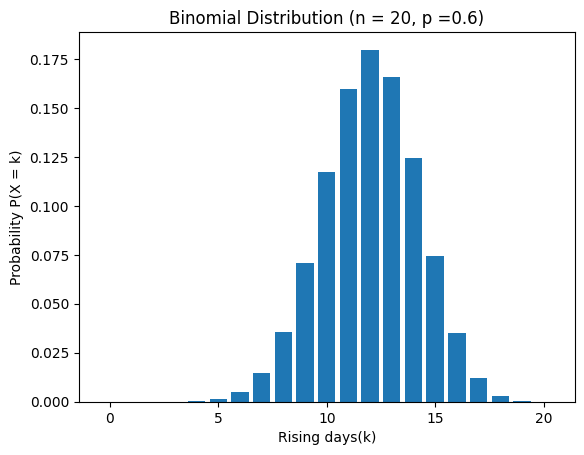

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom
n = 20    #總天數
p = 0.6   #單日上漲機率
x = np.arange(0, n+1)  #漲天數

pmf = binom.pmf(x,n,p)

plt.bar(x, pmf)
plt.xlabel("Rising days(k)")
plt.ylabel("Probability P(X = k)")
plt.title("Binomial Distribution (n = 20, p =0.6)")
plt.show()

<ipython-input-22-2805685425>:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("0050.TW", period = "1mo")
[*********************100%***********************]  1 of 1 completed


漲天數: 9, 總交易天數: 19


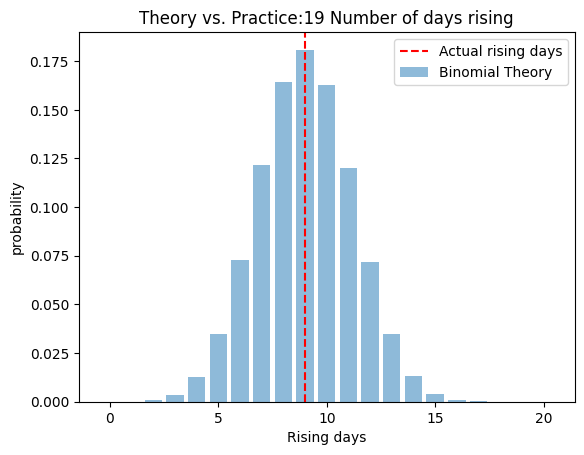

In [ ]:
#0050.TW 近一個月漲天數分析
import yfinance as yf

df = yf.download("0050.TW", period = "1mo")
df["Return"] = df["Close"].pct_change()
up_days = (df["Return"] > 0).sum()
total_days = df["Return"].count()

print(f"漲天數: {up_days}, 總交易天數: {total_days}")

p_hat = up_days / total_days  #實際單日上漲機率
pmf = binom.pmf(x, total_days, p_hat)

plt.bar(x, pmf, alpha = 0.5, label = "Binomial Theory")
plt.axvline(up_days, color = "r", linestyle = "--", label = "Actual rising days")
plt.xlabel("Rising days")
plt.ylabel("probability")
plt.title(f"Theory vs. Practice:{total_days} Number of days rising")
plt.legend()
plt.show()

<ipython-input-93-2938581916>:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df1 = yf.download("4420.TWO", period = "1mo")
[*********************100%***********************]  1 of 1 completed

漲天數: 7, 總交易天數: 20


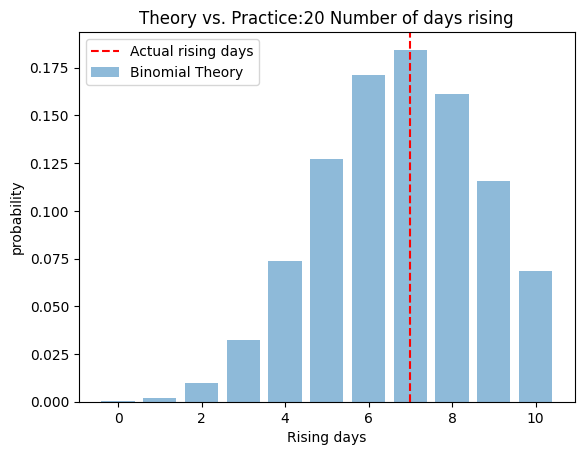

In [ ]:
#0056.TW 近一個月漲天數分析
import yfinance as yf

df1 = yf.download("4420.TWO", period = "1mo")
df1["Return"] = df1["Close"].pct_change()
up_days = (df1["Return"] > 0).sum()
total_days = df1["Return"].count()

print(f"漲天數: {up_days}, 總交易天數: {total_days}")

p_hat = up_days / total_days  #實際單日上漲機率
pmf = binom.pmf(x, total_days, p_hat)

plt.bar(x, pmf, alpha = 0.5, label = "Binomial Theory")
plt.axvline(up_days, color = "r", linestyle = "--", label = "Actual rising days")
plt.xlabel("Rising days")
plt.ylabel("probability")
plt.title(f"Theory vs. Practice:{total_days} Number of days rising")
plt.legend()
plt.show()

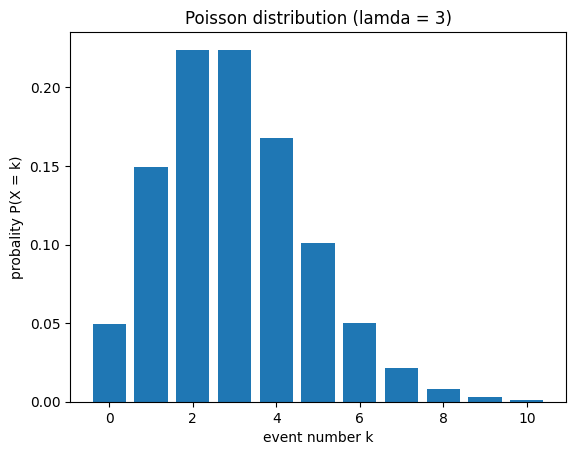

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
lam = 3
x = np.arange(0, 11)
pmf = poisson.pmf(x, lam)

plt.bar(x, pmf)
plt.xlabel("event number k")
plt.ylabel("probality P(X = k)")
plt.title("Poisson distribution (lamda = 3)")
plt.show()

In [ ]:
import yfinance as yf
import pandas as pd

df = yf.download("2330.TW", period = "1y")
df["Return"] = df["Close"].pct_change()
df["Extreme"] = df["Return"].abs() > 0.1
m_extreme = df.resample("ME").Extreme.sum()
result = pd.DataFrame(m_extreme.values, index = m_extreme.index, columns = ["Count"])
result.index = result.index.strftime("%Y-%m")
result

<ipython-input-102-36904771>:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("2330.TW", period = "1y")
[*********************100%***********************]  1 of 1 completed


,Count
Date,
2024-06,0
2024-07,0
2024-08,0
2024-09,0
2024-10,0
2024-11,0
2024-12,0
2025-01,0
2025-02,0


Average number of days with extreme volatility per week lamda = 0.000000


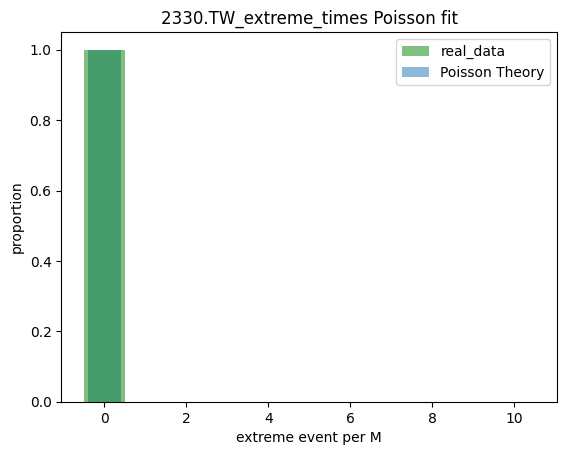

In [ ]:
from scipy.stats import poisson
lam = m_extreme.mean()
pmf = poisson.pmf(x, lam)
print(f"Average number of days with extreme volatility per week lamda = {lam:2f}")

plt.bar(x, pmf, alpha = 0.5, label = "Poisson Theory")
plt.hist(m_extreme, bins = np.arange(x.max()+2)-0.5, density = True, alpha = 0.5, label = "real_data", color = "green")

plt.xlabel("extreme event per M")
plt.ylabel("proportion")
plt.title("2330.TW_extreme_times Poisson fit")
plt.legend()
plt.show()


In [ ]:
((150*(2)**0.5 + 50)**2 + (150*(2)**0.5)**2)**0.5

337.2138838120347

# **常態分佈的圖形與解釋**

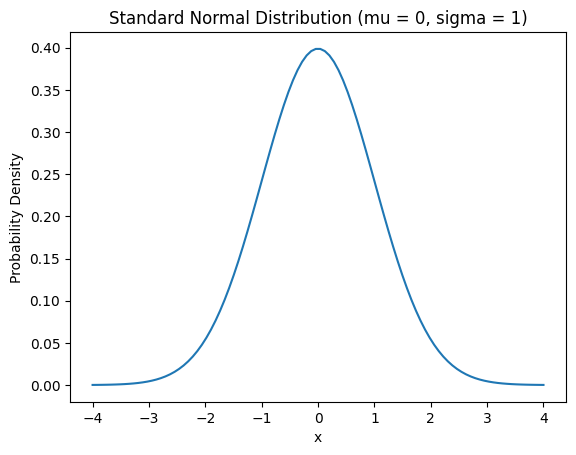

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

mu, sigma = 0, 1
x = np.linspace(-4, 4, 100)
y = norm.pdf(x, mu, sigma)
plt.plot(x, y)
plt.title("Standard Normal Distribution (mu = 0, sigma = 1)")
plt.xlabel("x")
plt.ylabel("Probability Density")
plt.show()

In [ ]:
import yfinance as yf
df = yf.download("AAPL", period = "1y")
df["Return"] = df["Close"].pct_change()
print(df[["Close", "Return"]].head())

<ipython-input-87-2926030021>:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", period = "1y")
[*********************100%***********************]  1 of 1 completed

Price            Close    Return
Ticker            AAPL          
Date                            
2024-06-18  213.292480       NaN
2024-06-20  208.703964 -0.021513
2024-06-21  206.524155 -0.010445
2024-06-24  207.171112  0.003133
2024-06-25  208.096817  0.004468


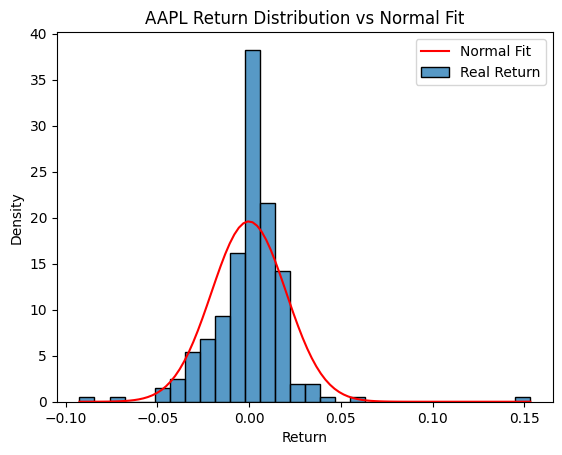

In [ ]:
import seaborn as sns
mu = df["Return"].mean()
sigma = df["Return"].std()
sns.histplot(df["Return"].dropna(), bins = 30, stat = "density", label = "Real Return")
x = np.linspace(df["Return"].min(), df["Return"].max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), label = "Normal Fit", color = "red")
plt.title("AAPL Return Distribution vs Normal Fit")
plt.legend()
plt.show()

# **QQ圖**

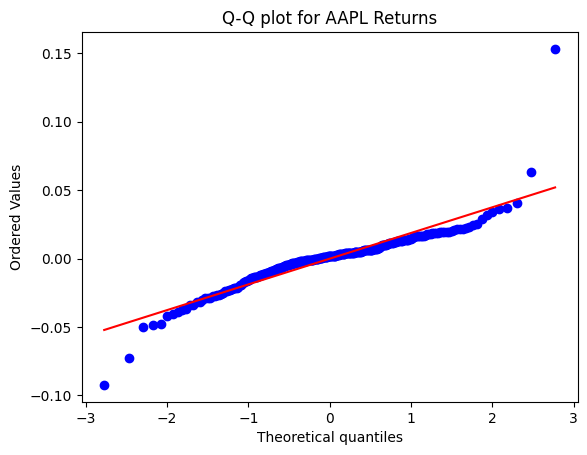

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt

stats.probplot(df["Return"].dropna(), dist = "norm", plot = plt)
plt.title("Q-Q plot for AAPL Returns")
plt.show()

In [ ]:
from scipy.stats import norm
mu = df["Return"].mean()
sigma = df["Return"].std()
ci_95 = norm.interval(0.95, loc = mu, scale = sigma)
print(f"95%信賴區間: {ci_95}")
#信賴區間越窄越好 --> 代表波動越小

95%信賴區間: (np.float64(-0.10432380521539387), np.float64(0.09874336177525912))


In [ ]:
df["zscore"] = (df["Return"] - mu) / sigma
print(df[["Return", "zscore"]].head())
print(df[df["zscore"].abs() > 2]["Return"])
print()
z_scale = len(df[df["zscore"].abs() > 2]["Return"]) / len(df["Return"])
print(f"extreme: {z_scale * 100}%")

Price         Return    zscore
Ticker                        
Date                          
2024-06-18       NaN       NaN
2024-06-20 -0.021513 -1.049537
2024-06-21 -0.010445 -0.505951
2024-06-24  0.003133  0.160847
2024-06-25  0.004468  0.226446
Date
2024-08-05   -0.048167
2025-03-10   -0.048480
2025-04-03   -0.092456
2025-04-04   -0.072887
2025-04-08   -0.049818
2025-04-09    0.153288
2025-04-10   -0.042394
2025-04-11    0.040594
2025-05-12    0.063146
Name: Return, dtype: float64

extreme: 3.5999999999999996%


<ipython-input-91-3620084599>:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df2 = yf.download("MSFT", period = "1y")
[*********************100%***********************]  1 of 1 completed


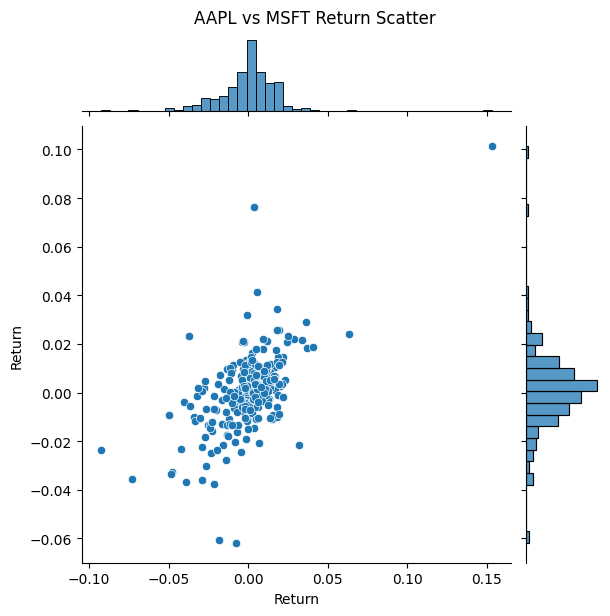

In [ ]:
df2 = yf.download("MSFT", period = "1y")
df2["Return"] = df2["Close"].pct_change()
import seaborn as sns
sns.jointplot(x = df["Return"], y = df2["Return"], kind = "scatter")
plt.suptitle("AAPL vs MSFT Return Scatter", y = 1.02)
plt.show()

In [ ]:
import yfinance as yf
import numpy as np
from scipy.stats import norm
#下載資料
df = yf.download("SPY", period = "1y")
df["Return"] = df["Close"].pct_change()
mu = df["Return"].mean()
sigma = df["Return"].std()
alpha = 0.05  #95%信心水準的左尾
z_alpha = norm.ppf(alpha) #約為 -1.645
VaR_95 = mu + sigma * z_alpha
print(f"SPY 單日VaR(95%信心水準): {VaR_95:.4f}({VaR_95*100:.2f})")

<ipython-input-108-2118825302>:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("SPY", period = "1y")
[*********************100%***********************]  1 of 1 completed

SPY 單日VaR(95%信心水準): -0.0208(-2.08)


<ipython-input-109-1445401451>:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("0050.TW", period = "1y")
[*********************100%***********************]  1 of 1 completed


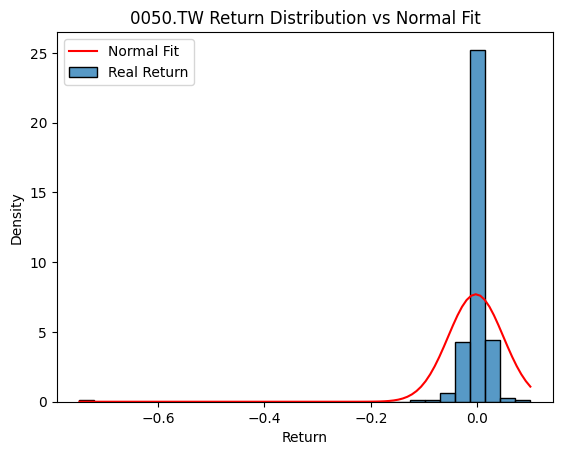

In [ ]:
import yfinance as yf
import numpy as np
from scipy.stats import norm
import seaborn as sns
import matplotlib.pyplot as plt

df = yf.download("0050.TW", period = "1y")
df["Return"] = df["Close"].pct_change()
mu = df["Return"].mean()
sigma = df["Return"].std()
sns.histplot(df["Return"].dropna(), bins = 30, stat = "density", label = "Real Return")
x = np.linspace(df["Return"].min(), df["Return"].max(), 100)
plt.plot(x, norm.pdf(x, mu, sigma), label = "Normal Fit", color = "red")
plt.title("0050.TW Return Distribution vs Normal Fit")
plt.legend()
plt.show()


<ipython-input-110-2474079196>:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("0050.TW", period = "1y")
[*********************100%***********************]  1 of 1 completed


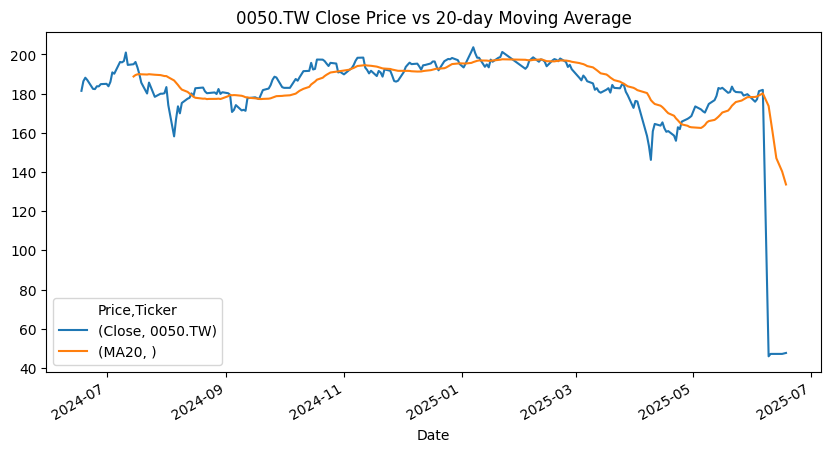

In [ ]:
import pandas as pd
import yfinance as yf
df = yf.download("0050.TW", period = "1y")
df["MA20"] = df["Close"].rolling(window = 20).mean()
df["STD20"] = df["Close"].rolling(window = 20).std()
df[["Close", "MA20"]].plot(figsize = (10, 5))
plt.title("0050.TW Close Price vs 20-day Moving Average")
plt.show()

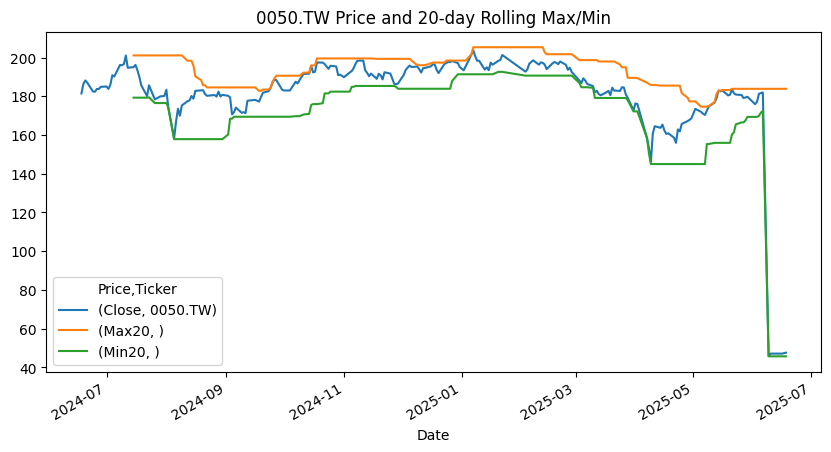

In [ ]:
df["Max20"] = df["High"].rolling(window = 20).max()
df["Min20"] = df["Low"].rolling(window = 20).min()
df[["Close", "Max20", "Min20"]].plot(figsize = (10, 5))
plt.title("0050.TW Price and 20-day Rolling Max/Min")
plt.show()

In [ ]:
df["PosDay20"] = df["Return"].rolling(20).apply(lambda x:(x > 0).sum())
plt.plot(df["PosDay20"])
plt.title("Positive pay days within 20-day window")
plt.show()

KeyError: 'Return'

In [ ]:
import pandas as pd
import yfinance as yf
df = yf.download("0050.TW", period = "1y")
#df["P20"] = df["Close"].rolling(window = 20)
df["MA20"] = df["Close"].rolling(window = 20).mean()
df["STD20"] = df["Close"].rolling(window = 20).std()

<ipython-input-115-2145649866>:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("0050.TW", period = "1y")
[*********************100%***********************]  1 of 1 completed


In [ ]:
import yfinance as yf
df = yf.download("0050.TW", period = "1y")
df["Return"] = df["Close"].pct_change()
returns = df["Return"].dropna()
print(returns.head())
skew = returns.skew()
kurt = returns.kurt()
print(f"偏態: {skew:.4f}, 峯態: {kurt:.4f}")


<ipython-input-117-2546964061>:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("0050.TW", period = "1y")
[*********************100%***********************]  1 of 1 completed

Date
2024-06-19    0.027049
2024-06-20    0.009577
2024-06-21   -0.006061
2024-06-24   -0.024390
2024-06-25   -0.000544
Name: Return, dtype: float64
偏態: -12.5388, 峯態: 180.4352


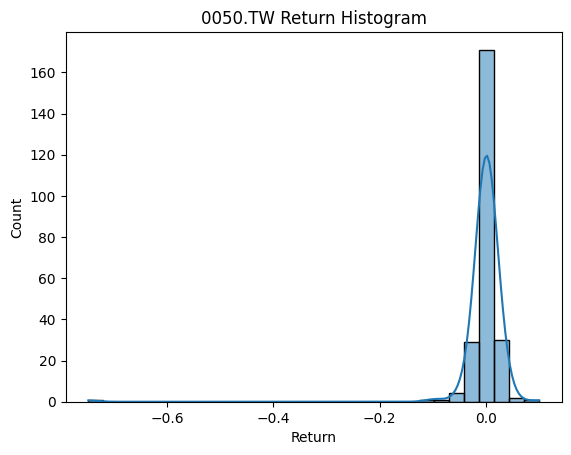

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(returns, bins = 30, kde = True)
plt.title("0050.TW Return Histogram")
plt.show()

In [ ]:
from scipy.stats import jarque_bera

jb_stat, jb_p = jarque_bera(returns)
print(f"JB統計量: {jb_stat:.2f}, p-value: {jb_p:.4f}")

JB統計量: 318344.11, p-value: 0.0000


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

#設定股票代碼
tickers = ["GS", "GOOGL", "JPM", "RTX"]
#設定時間範圍
s = "2024-01-01"
e = "2025-06-04"

#下載歷史股價數據
data = yf.download(tickers, start = s, end = e)["Close"]
data

/tmp/ipython-input-89-1365464813.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start = s, end = e)["Close"]
[*********************100%***********************]  4 of 4 completed


Ticker,GOOGL,GS,JPM,RTX
Date,,,,
2024-01-02,137.346298,375.374573,166.179550,82.425461
2024-01-03,138.091812,369.081268,165.455261,82.802673
2024-01-04,135.576904,370.202606,166.553253,82.609245
2024-01-05,134.920837,373.576477,167.388885,82.580208
2024-01-08,138.012283,375.915924,167.145981,83.025124
...,...,...,...,...
2025-05-28,172.151596,605.422241,263.489990,132.850006
2025-05-29,171.652191,601.859985,264.369995,134.800003
2025-05-30,171.532349,600.450012,264.000000,136.479996


In [ ]:
returns = data.pct_change().dropna()
returns

Ticker,GOOGL,GS,JPM,RTX
Date,,,,
2024-01-03,0.005428,-0.016765,-0.004358,0.004576
2024-01-04,-0.018212,0.003038,0.006636,-0.002336
2024-01-05,-0.004839,0.009114,0.005017,-0.000352
2024-01-08,0.022913,0.006262,-0.001451,0.005388
2024-01-09,0.015198,-0.013167,-0.007906,-0.000466
...,...,...,...,...
2025-05-28,-0.003123,-0.011840,-0.006785,-0.009986
2025-05-29,-0.002901,-0.005884,0.003340,0.014678
2025-05-30,-0.000698,-0.002343,-0.001400,0.012463


In [ ]:
expected_returns = returns.mean() * 252
print("\n預期回報 (年化):\n", expected_returns)

covariance_matrix = returns = returns.cov() * 252
print("\n共變異數矩陣 (年化):\n", covariance_matrix)

correlation_matrix = returns.corr()
print("\n相關係數矩陣:\n", correlation_matrix)


預期回報 (年化):
 Ticker
GOOGL    0.182414
GS       0.384267
JPM      0.368235
RTX      0.390974
dtype: float64

共變異數矩陣 (年化):
 Ticker     GOOGL        GS       JPM       RTX
Ticker                                        
GOOGL   0.096259  0.036566  0.024571  0.009029
GS      0.036566  0.094260  0.065726  0.024456
JPM     0.024571  0.065726  0.067077  0.022276
RTX     0.009029  0.024456  0.022276  0.054610

相關係數矩陣:
 Ticker     GOOGL        GS       JPM       RTX
Ticker                                        
GOOGL   1.000000 -0.109940 -0.301489 -0.811588
GS     -0.109940  1.000000  0.911124 -0.367363
JPM    -0.301489  0.911124  1.000000 -0.290657
RTX    -0.811588 -0.367363 -0.290657  1.000000


In [ ]:
weights = np.array([1/12, 4/12, 4/12, 3/12])

portfolio_expected_return = np.dot(weights, expected_returns)
print("\n投資組合預期回報 (年化):", portfolio_expected_return)

portfolio_variance = np.dot(weights.T, np.dot(covariance_matrix, weights))
print("投資組合變異數 (年化):", portfolio_variance)


投資組合預期回報 (年化): 0.3637786953366152
投資組合變異數 (年化): 0.048175295461502544


In [ ]:
portfolio_STD = np.sqrt(portfolio_variance)
print("投資組合標準差 (年化):", portfolio_STD)

risk_free_rate = 0.02

sharpe_ratio = (portfolio_expected_return - risk_free_rate) / portfolio_STD
print("投資組合夏普比率", sharpe_ratio)

投資組合標準差 (年化): 0.21948871374515488
投資組合夏普比率 1.5662704904989857


# **股價組合以及夏普比率  此處為本notebook的重點**

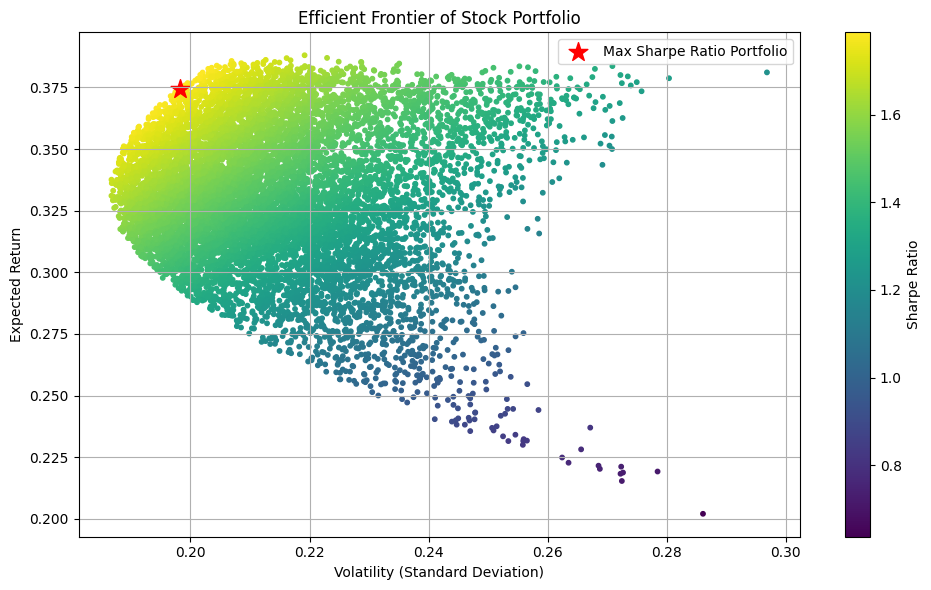


 具有最高夏普比率的投資組合:
回報: 0.3745
波動性: 0.1982
夏普比率: 1.7886
權重: {'GS': np.float64(0.03930812740485305), 'GOOGL': np.float64(0.013236144839450665), 'JPM': np.float64(0.35991374096669004), 'RTX': np.float64(0.5875419867890062)}


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

#生成隨機投資組合權重
num_portfolios = 10000 #生成10000個隨機投資組合
portfolio_returns = []
portfolio_volatilities = []
sharpe_ratios = []
portfolio_weights_list = []
for _ in range(num_portfolios):
  weights = np.random.random(len(tickers))
  weights /= np.sum(weights)
  portfolio_weights_list.append(weights)

  portfolio_return = np.dot(weights, expected_returns)
  portfolio_returns.append(portfolio_return)

  portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(covariance_matrix, weights)))
  portfolio_volatilities.append(portfolio_volatility)

  sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
  sharpe_ratios.append(sharpe_ratio)

portfolio_results = pd.DataFrame({
    'Returns': portfolio_returns,
    'Volatility': portfolio_volatilities,
    'Sharpe Ratio': sharpe_ratios,
    'Weights': portfolio_weights_list})

max_sharpe_ratio_portfolio = portfolio_results.iloc[portfolio_results['Sharpe Ratio'].idxmax()]

plt.figure(figsize=(10, 6))
plt.scatter(portfolio_results['Volatility'], portfolio_results['Returns'],
c=portfolio_results['Sharpe Ratio'], cmap='viridis', marker='o', s=10)
plt.colorbar(label='Sharpe Ratio')
plt.scatter(max_sharpe_ratio_portfolio['Volatility'],
max_sharpe_ratio_portfolio['Returns'], color='red', marker='*', s=200, label='Max Sharpe Ratio Portfolio')
plt.xlabel('Volatility (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier of Stock Portfolio')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n 具有最高夏普比率的投資組合:")
print(f"回報: {max_sharpe_ratio_portfolio['Returns']:.4f}")
print(f"波動性: {max_sharpe_ratio_portfolio['Volatility']:.4f}")
print(f"夏普比率: {max_sharpe_ratio_portfolio['Sharpe Ratio']:.4f}")
print(f"權重: {dict(zip(tickers, max_sharpe_ratio_portfolio['Weights']))}")








In [ ]:
import yfinance as yf
import numpy as np
import statsmodels.api as sm

aapl = yf.download("AAPL", period = "1y")["Close"]
spx = yf.download("^GSPC", period = "1y")["Close"]

aapl_ret = aapl.pct_change().dropna()
spx_ret = spx.pct_change().dropna()

X = sm.add_constant(spx_ret)
model = sm.OLS(aapl_ret, X)
result = model.fit()
print(result.summary())

/tmp/ipython-input-99-587003670.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  aapl = yf.download("AAPL", period = "1y")["Close"]
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-99-587003670.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  spx = yf.download("^GSPC", period = "1y")["Close"]
[*********************100%***********************]  1 of 1 completed

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     363.4
Date:                Thu, 19 Jun 2025   Prob (F-statistic):           1.95e-50
Time:                        03:21:03   Log-Likelihood:                 729.99
No. Observations:                 249   AIC:                            -1456.
Df Residuals:                     247   BIC:                            -1449.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0006      0.001     -0.706      0.4

In [ ]:
alpha = result.params["const"]
beta = result.params["^GSPC"]
r2 = result.rsquared
print(f"alpha(截距): {alpha:.5f}, beta(斜率): {beta:.5f}, R^2:{r2:.4f}")

alpha(截距): -0.00058, beta(斜率): 1.25143, R^2:0.5954


In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm

RISK_FREE_RATE = 0.02

ticker = "2330.TW"
market = "^TWII"
Period = "5y"
#_2330 = yf.download("2330.TW", period = "5y")["Close"]
#TWII = yf.download("^TWII", period = "5y")["Close"]
data = yf.download([ticker, market], period = Period)["Close"]

#_2330_ret = _2330.pct_change().dropna()
#TWII_ret = TWII.pct_change().dropna()

returns = data.pct_change().dropna()
returns_ret = returns.pct_change().dropna()
returns_ret.columns = ["Stock_Ret", "Market_Ret"]
returns_ret

/tmp/ipython-input-120-402444677.py:13: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download([ticker, market], period = Period)["Close"]
[*********************100%***********************]  2 of 2 completed


,Stock_Ret,Market_Ret
Date,,
2020-06-23,-2.209610,0.705817
2020-06-24,-0.174588,0.221018
2020-06-29,-3.182656,-3.433487
2020-06-30,-1.185030,-1.672802
2020-07-01,3.485424,0.038204
...,...,...
2025-06-13,-0.017904,0.188442
2025-06-16,-0.661812,-0.891688
2025-06-17,-5.019512,-8.022416


In [ ]:
y = returns_ret["Stock_Ret"]
X = sm.add_constant(returns_ret["Market_Ret"])
model = sm.OLS(y, X).fit()
beta = model.params["Market_Ret"]

market_return_annual = returns_ret["Market_Ret"].mean() * 252

expected_return = RISK_FREE_RATE + beta * (market_return_annual - RISK_FREE_RATE)

In [ ]:
print(f"---CAPM 分析報告 :{ticker}---")
print(f"分析期間: 最近{Period}")
print(f"計算出的Beta(beta):{beta:.4f}")
print(f"歷史市場年化報酬率(Rm):{market_return_annual:.2%}")
print(f"假設無風險利率 (Rf):{RISK_FREE_RATE:.2%}")
print("-"*30)
print(f"模型預期年報酬率 E(Ri):{expected_return:.2%}")
print("-"*30)



---CAPM 分析報告 :2330.TW---
分析期間: 最近5y
計算出的Beta(beta):nan
歷史市場年化報酬率(Rm):-1292.70%
假設無風險利率 (Rf):2.00%
------------------------------
模型預期年報酬率 E(Ri):nan%
------------------------------
